# Pregunta 1: Saturación Selectiva de Color (20 puntos)

Implemente una herramienta `ColorSaturation` que permita modificar selectivamente la saturación de una imagen RGB en función de su tono. La herramienta deberá recibir como mínimo una imagen RGB, un conjunto arbitrario de puntos de control $(h_i, m_i)$ y un parámetro que seleccione el espacio de color utilizado.

La herramienta deberá disponer de dos modos:
* **Modo HS:** utilice un espacio de color basado en tono y saturación (por ejemplo HSV, HSL o HSI). Puede escoger el modelo, pero debe indicar cuál utiliza y mantener sin modificación las componentes que no correspondan al tono y a la saturación.
* **Modo CIE $L^*C^*h^*$:** utilice $h^*$ para seleccionar los colores y modifique $C^*$, manteniendo $L^*$ y $h^*$ sin modificación.

Los puntos de control definen un mapeo $m(h)$ desde el tono hacia un parámetro real de amplificación o atenuación. El valor $m(h)$ deberá obtenerse mediante interpolación lineal por tramos entre los puntos de control. Como el tono es periódico, la interpolación debe tratar correctamente la transición entre el final y el inicio del intervalo, evitando discontinuidades alrededor del rojo.

El valor $m(h)$ no determina por sí solo la saturación o croma de salida. El diseño de la transformación es parte de la tarea: defina una familia de funciones $g_m$ que, para cualquier valor real $m$ dentro de un rango que usted puede limitar, transforme la componente original:
$$S' = g_{m(h)}(S) \quad \text{o} \quad C^{*\prime} = g_{m(h^*)}(C^*)$$

Debe definir claramente un valor neutro del parámetro $m$ que deje la componente sin cambios, así como el comportamiento correspondiente a amplificación y atenuación. La forma de $g_m$ es libre, pero debe estar justificada y comportarse de manera estable para todo el rango de $m$ utilizado.

---


In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os
sys.path.append('..')

import numpy as np
import matplotlib.pyplot as plt

from codigo.p1_saturacion import ColorSaturation, interpolar_m_periodico, funcion_g_m, rgb_a_lch
from codigo.utilidades import cargar_imagen_rgb, graficar_triptico

os.makedirs('../figuras/p1', exist_ok=True)
print("Configuración lista.")

Configuración lista.



## P1 — Experimentación y Análisis (8 puntos)
1. **Configuraciones de control:** 
---



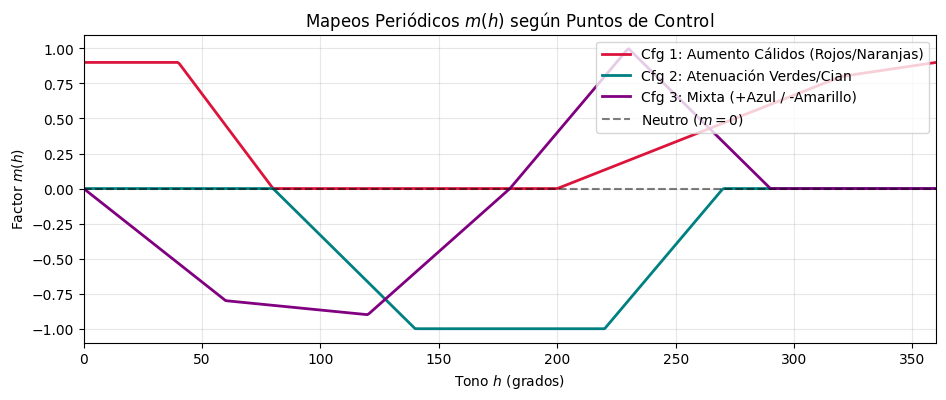

In [2]:
# Definición de las 3 configuraciones obligatorias (h en grados [0, 360), m en [-1, 1])
cfg_aumento = [(0, 0.9), (40, 0.9), (80, 0.0), (200, 0.0), (320, 0.8)]       # 1. Aumento de cálidos/rojos
cfg_atenuacion = [(0, 0.0), (80, 0.0), (140, -1.0), (220, -1.0), (270, 0.0)]  # 2. Atenuación de verdes/cian
cfg_mixta = [(0, 0.0), (60, -0.8), (120, -0.9), (180, 0.0), (230, 1.0), (290, 0.0)] # 3. Mixta (+Azul / -Amarillo)

h_grilla = np.linspace(0, 360, 500)

plt.figure(figsize=(11, 4))
plt.plot(h_grilla, interpolar_m_periodico(h_grilla, cfg_aumento), label="Cfg 1: Aumento Cálidos (Rojos/Naranjas)", color="crimson", lw=2)
plt.plot(h_grilla, interpolar_m_periodico(h_grilla, cfg_atenuacion), label="Cfg 2: Atenuación Verdes/Cian", color="teal", lw=2)
plt.plot(h_grilla, interpolar_m_periodico(h_grilla, cfg_mixta), label="Cfg 3: Mixta (+Azul / -Amarillo)", color="purple", lw=2)
plt.axhline(0, color="black", linestyle="--", alpha=0.5, label="Neutro ($m=0$)")

plt.title("Mapeos Periódicos $m(h)$ según Puntos de Control", fontsize=12)
plt.xlabel("Tono $h$ (grados)")
plt.ylabel("Factor $m(h)$")
plt.xlim(0, 360)
plt.grid(True, alpha=0.3)
plt.legend(loc="upper right")
plt.savefig("../figuras/p1/01_curvas_control_m.png", dpi=300, bbox_inches="tight")
plt.show()

2. **Aplicación en imágenes:** 
---

In [3]:
# Carga de las dos imágenes reales desde datos/originales/
img1 = cargar_imagen_rgb("P1_IMG_2402.tif")
img2 = cargar_imagen_rgb("P2_IMG_2423.tif")

# Aplicamos la configuración mixta a ambas imágenes
img1_hs = ColorSaturation(img1, cfg_mixta, modo="HS")
img1_lch = ColorSaturation(img1, cfg_mixta, modo="LCh")

img2_hs = ColorSaturation(img2, cfg_mixta, modo="HS")
img2_lch = ColorSaturation(img2, cfg_mixta, modo="LCh")

3. **Comparación HS vs. $L^*C^*h^*$:** 
---

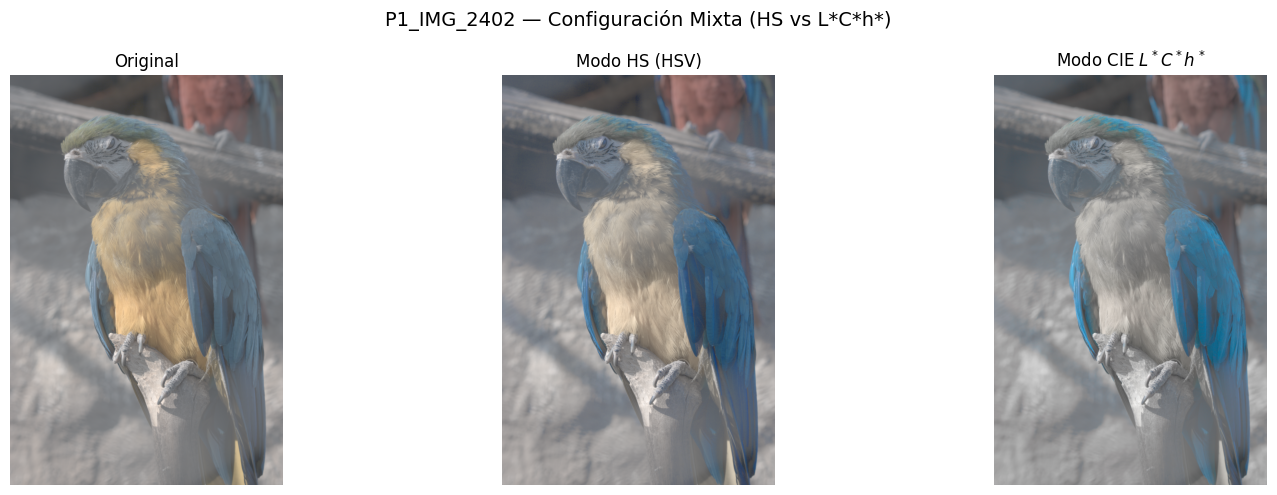

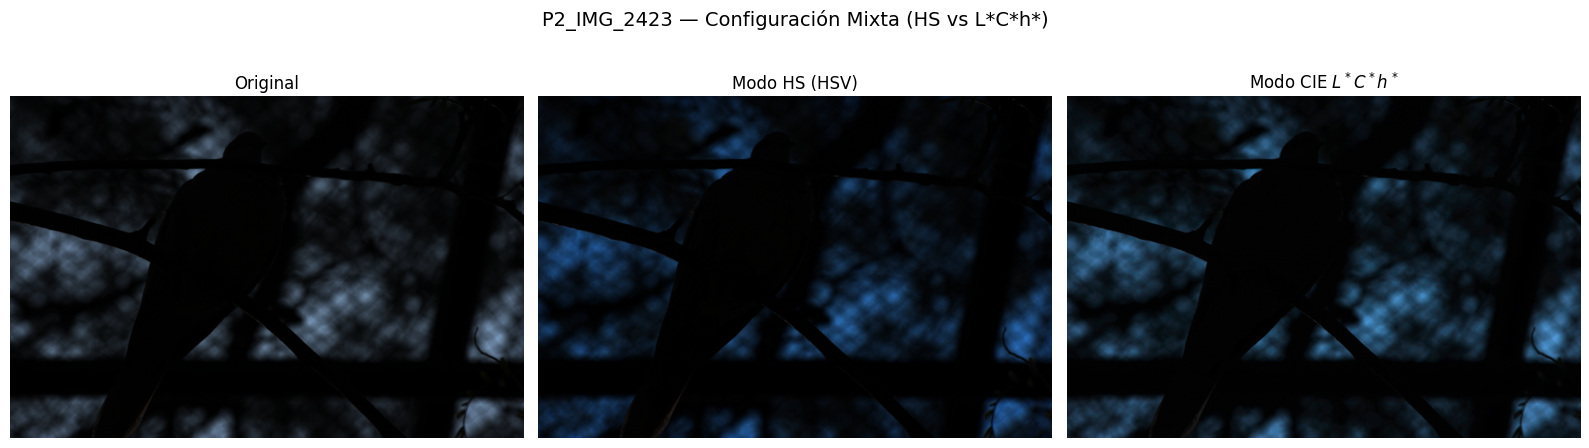

In [4]:
# Visualización y exportación
graficar_triptico(img1, img1_hs, img1_lch, 
                  titulo="P1_IMG_2402 — Configuración Mixta (HS vs L*C*h*)",
                  ruta_guardado="../figuras/p1/02_comparacion_img1_mixta.png")

graficar_triptico(img2, img2_hs, img2_lch, 
                  titulo="P2_IMG_2423 — Configuración Mixta (HS vs L*C*h*)",
                  ruta_guardado="../figuras/p1/03_comparacion_img2_mixta.png")

Al probar la configuración mixta sobre las imágenes originales proporcionadas (`P1_IMG_2402` y `P2_IMG_2423`), se aprecia de inmediato que ambos métodos afectan exactamente a los mismos intervalos cromáticos: los tonos azules reciben un realce, mientras que los amarillos y verdes experimentan una atenuación. Sin embargo, la forma en que el ojo percibe estos cambios es notablemente distinta. En el modo HS, al atenuar los amarillos, los objetos adquieren un aspecto "lavado", como si se hubiese aplicado una capa de neblina o se hubiera alterado el brillo de la superficie. En cambio, en el modo CIE $L^*C^*h^*$, esa misma atenuación apaga el color de forma muy limpia, convirtiéndolo en un gris neutro que respeta con fidelidad las luces, sombras y el volumen original de los elementos.

La razón técnica de esta diferencia esta en el diseño y la naturaleza psicofísica de cada espacio de color. El modelo HSV es una formulación geométrica artificial construida a partir de deformaciones del cubo RGB, sin correlato con la percepción biológica humana. Como vimos en la materia sobre la curva de sensibilidad fotópica $V(\lambda)$, el ojo humano no percibe la misma luminosidad ante un estímulo verde que ante uno azul. En HSV, la componente de brillo ($V = \max(R, G, B)$) no representa la luminancia real percibida; por eso, al manipular únicamente la saturación $S$, se modifica de manera indirecta el contraste y la claridad aparente de la escena.

Por el contrario, el estándar CIE $L^*a^*b^*$ (y su contraparte cilíndrica $L^*C^*h^*$) se concibió específicamente para lograr uniformidad perceptual. En este espacio, el canal de luminosidad calibrada $L^*$ se encuentra desacoplado ortogonalmente del plano cromático ($a^*, b^*$). Modificar el croma $C^*$ mediante $g_m$ altera de manera pura la vivacidad o pureza espectral sin mover un solo ápice la reflectancia aparente de las superficies, logrando un resultado visual mucho más orgánico y libre de distorsiones en el claroscuro.

4. **Exploración paramétrica:**
---

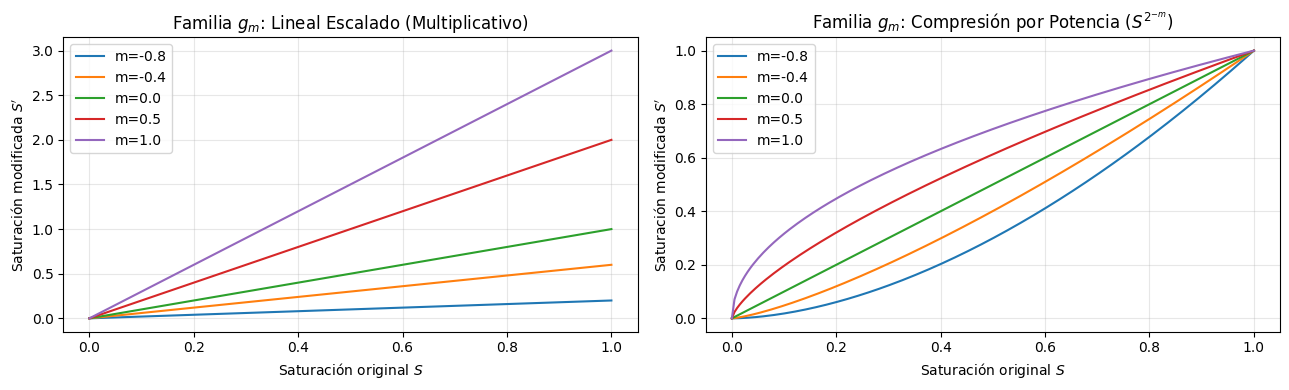

In [5]:
# Comparación de familias de funciones g_m: Lineal Escalada vs Potencia
S_vals = np.linspace(0, 1, 200)
m_samples = [-0.8, -0.4, 0.0, 0.5, 1.0]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for m_val in m_samples:
    axes[0].plot(S_vals, funcion_g_m(S_vals, np.full_like(S_vals, m_val), metodo="lineal_escalado"), label=f"m={m_val}")
    axes[1].plot(S_vals, funcion_g_m(S_vals, np.full_like(S_vals, m_val), metodo="potencia"), label=f"m={m_val}")

axes[0].set_title("Familia $g_m$: Lineal Escalado (Multiplicativo)")
axes[0].set_xlabel("Saturación original $S$")
axes[0].set_ylabel("Saturación modificada $S'$")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].set_title("Familia $g_m$: Compresión por Potencia ($S^{2^{-m}}$)")
axes[1].set_xlabel("Saturación original $S$")
axes[1].set_ylabel("Saturación modificada $S'$")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.savefig("../figuras/p1/04_familias_gm.png", dpi=300, bbox_inches="tight")
plt.show()

Al explorar el rango del parámetro $m$, el intervalo $m \in [-1, 1]$ resulta intuitivo y bien condicionado. En el extremo negativo ($m \rightarrow -1$), la formulación lineal escalada anula por completo la componente cromática ($\alpha(-1) = 0$), colapsando los tonos seleccionados hacia niveles de gris. En el extremo positivo ($m \rightarrow 1$), la ganancia multiplica por tres la saturación inicial ($\alpha(1) = 3$), un valor suficiente para revitalizar tonos apagados sin inducir de inmediato deformaciones extremas. Si la amplitud se eleva más allá de este rango (por ejemplo, hacia $m=3$), los colores se vuelven artificiales y se precipita la saturación del espacio.

La ubicación y separación de los nodos de control en el círculo de matiz juega un rol determinante en la continuidad visual de la imagen:

* Si los puntos de control se sitúan con una separación holgada (por ejemplo, entre $40^\circ$ y $60^\circ$ de distancia), la interpolación lineal por tramos genera pendientes suaves, permitiendo que las transiciones de color en gradientes naturales y degradados ocurran de forma imperceptible.


* Si, en cambio, se colocan puntos muy cercanos entre sí (con distancias inferiores a $15^\circ$), la pendiente $\frac{dm}{dh}$ se vuelve casi vertical. Esto introduce bordes duros artificiales, bandas de color abruptas (*banding*) e incrementa el ruido en transiciones sutiles, como las presentes en la piel o fondos desenfocados.



Respecto al diseño matemático de la familia $g_m$, la comparación entre el modelo **lineal escalado** y el de **compresión por potencia** ($S^{2^{-m}}$) evidencia compromisos claros:

* El enfoque lineal escalado es directo, predecible y preserva de forma fiel las diferencias relativas entre saturaciones bajas. Sin embargo, tiene una falta de una asíntota superior natural, lo que provoca que píxeles que ya poseían una saturación media o alta alcancen los límites dinámicos muy rápido.


* La familia basada en potencias garantiza por construcción que cualquier valor en $[0, 1]$ se conserve dentro de $[0, 1]$, eliminando el riesgo de rebasar la cota máxima. Su comportamiento es análogo a una curva gamma aplicada al croma: actúa con fuerza sobre los tonos medios, pero sacrifica la respuesta lineal y comprime el contraste cromático en las zonas más vívidas.

5. **Casos límite / clipping:**
---

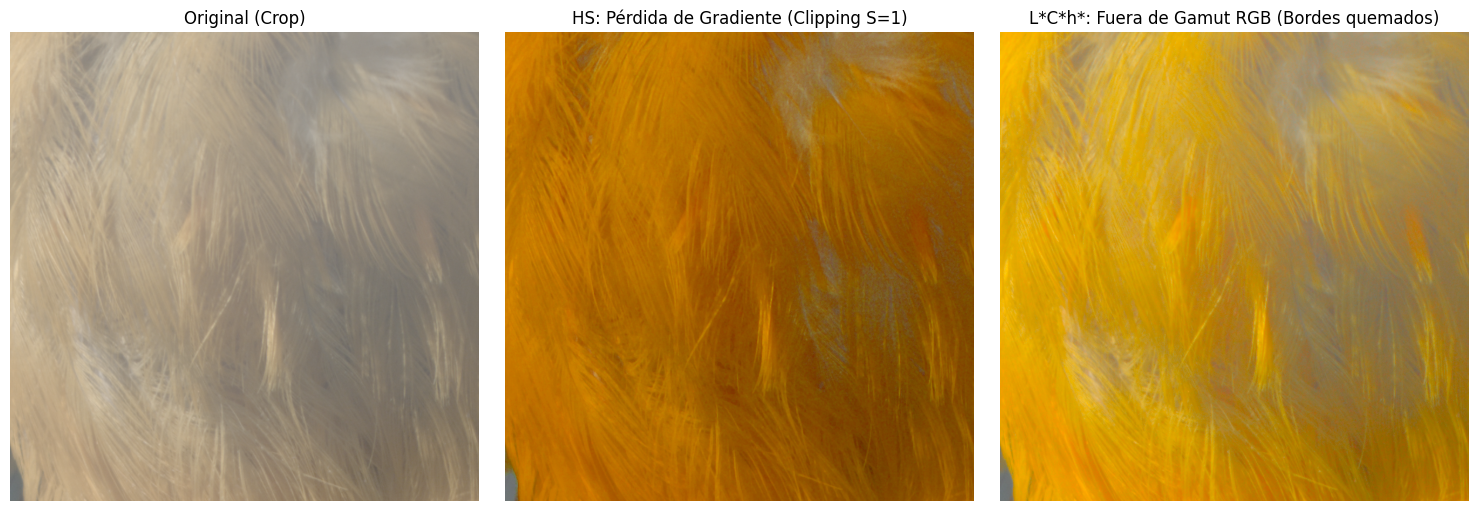

In [6]:
# Provocar saturación extrema con m=3.0 en tonos cálidos
cfg_extrema = [(0, 3.0), (60, 3.0), (120, 0.0), (300, 0.0)]

img1_extrema_hs = ColorSaturation(img1, cfg_extrema, modo="HS", metodo_gm="lineal_escalado")
img1_extrema_lch = ColorSaturation(img1, cfg_extrema, modo="LCh", metodo_gm="lineal_escalado")

# Recorte ampliado (crop) para visualizar artefactos de clipping
crop_y, crop_x = slice(1800, 2600), slice(1200, 2000)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img1[crop_y, crop_x])
axes[0].set_title("Original (Crop)")
axes[0].axis("off")

axes[1].imshow(img1_extrema_hs[crop_y, crop_x])
axes[1].set_title("HS: Pérdida de Gradiente (Clipping S=1)")
axes[1].axis("off")

axes[2].imshow(img1_extrema_lch[crop_y, crop_x])
axes[2].set_title("L*C*h*: Fuera de Gamut RGB (Bordes quemados)")
axes[2].axis("off")

plt.tight_layout()
plt.savefig("../figuras/p1/05_clipping_gamut.png", dpi=300, bbox_inches="tight")
plt.show()


Cuando se lleva la amplificación a niveles desmedidos —como se experimentó al fijar $m = 3.0$ ($\alpha(3) = 7.0$) sobre tonos cálidos— se evidencia de manera directa cómo reacciona cada espacio frente a la saturación de los límites físicos. En estas condiciones extremas, el comportamiento diverge por completo según el modo de operación utilizado:

En el modo **HS**, el límite superior está acotado en el propio espacio mediante la restricción $S \in [0, 1]$. Al aplicar un factor multiplicativo tan severo, una gran cantidad de píxeles con saturaciones moderadas son empujados inmediatamente hacia el valor máximo $S = 1.0$. Esto genera un recorte plano (*hard clipping*) que elimina por completo el gradiente interno y la textura de las zonas afectadas; el área pierde todo detalle fino y se convierte en un parche uniforme de color plano y artificial.

En el modo **CIE $L^*C^*h^*$**, el fenómeno es más sutil pero más complejo. A diferencia de la saturación cilíndrica, el croma $C^*$ no tiene un límite intrínseco dentro del espacio $L^*a^*b^*$. Sin embargo, al transformar las coordenadas $(a^*, b^*)$ de regreso al cubo de color de destino (sRGB), los valores calculados exigen componentes RGB negativas o superiores a $1.0$, es decir, caen fuera del *gamut* reproducible por el monitor. La respuesta del algoritmo consiste en recortar rígidamente estos canales mediante `np.clip` en $[0, 1]$. Este truncamiento geométrico introduce artefactos en las fronteras de los objetos ("bordes quemados") y provoca un corrimiento o viraje espurio del tono original ($h^*$), ya que al fijar un canal en $1.0$ mientras los otros continúan variando, se modifica la proporción relativa entre componentes y se distorsiona el matiz percibido.

6. **Exploración adicional libre:**
---

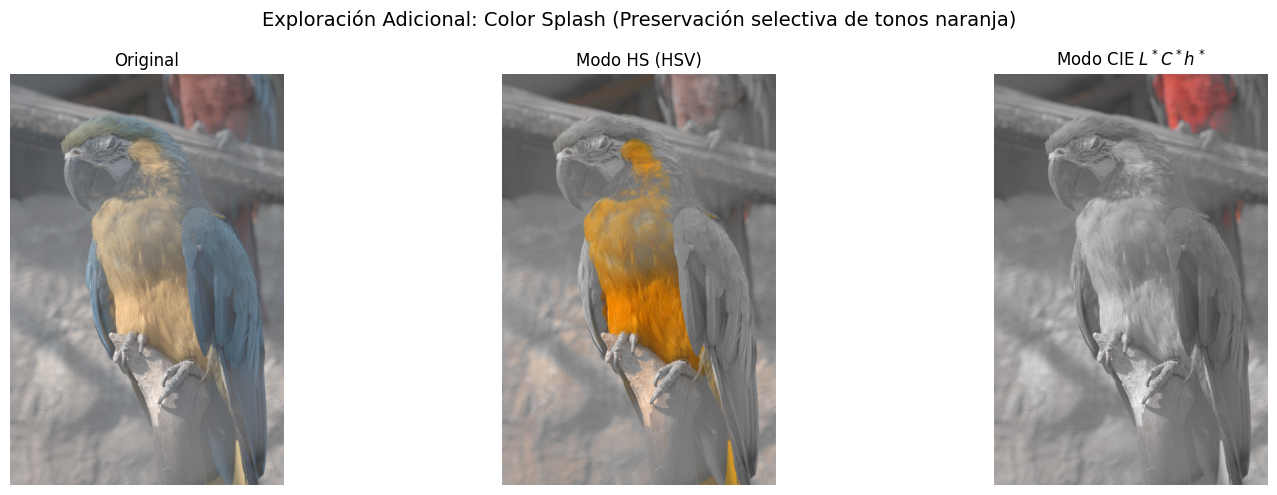

In [7]:
# Exploración libre: Desaturación global total salvo un estrecho ancho de banda cromático
cfg_splash = [(0, -1.0), (20, 0.8), (40, 0.8), (60, -1.0), (180, -1.0), (300, -1.0)]

splash_hs = ColorSaturation(img1, cfg_splash, modo="HS")
splash_lch = ColorSaturation(img1, cfg_splash, modo="LCh")

graficar_triptico(img1, splash_hs, splash_lch, 
                  titulo="Exploración Adicional: Color Splash (Preservación selectiva de tonos naranja)",
                  ruta_guardado="../figuras/p1/06_exploracion_libre_splash.png")

Como exploración libre se implementó una técnica de aislamiento cromático selectivo (*Color Splash*), ampliamente utilizada en posproducción y fotografía publicitaria para dirigir el foco de atención hacia una estructura clave mediante la desaturación selectiva del entorno circundante.

En este experimento, el objetivo consistió en aislar con precisión los tonos amarillos y anaranjados del pecho del guacamayo (`P1_IMG_2402.tif`), forzando a una escala acromática tanto el plumaje azul de las alas como la madera del tronco y el fondo desenfocado. Para ello, se configuró un filtro de paso de banda angular definido por los puntos de control:
$$\text{cfg\_splash} = [(0, -1.0), (20, 0.8), (40, 0.8), (60, -1.0), (180, -1.0), (300, -1.0)]$$
Esta curva concentra una ganancia positiva en el intervalo de matiz $[20^\circ, 40^\circ]$ y establece una anulación total ($m = -1.0$) en el resto del círculo cromático.

El análisis de los resultados destaca dos aspectos clave de la implementación:

* **Continuidad periódica y transiciones suaves:** Gracias a la interpolación modular en el dominio $[0, 360^\circ)$, la frontera del rojo en el origen no introduce saltos discontinuos. Además, los tramos lineales intermedios entre $0^\circ \text{--} 20^\circ$ y $40^\circ \text{--} 60^\circ$ actúan como una zona de transición suave (*feathering* angular). Esto evita la aparición de bordes dentados o ruido de falso color en el contorno del plumaje del ave.

* **Fidelidad fotométrica en CIE $L^*C^*h^*$ vs. HSV:** El fondo desaturado con $L^*C^*h^*$ mantiene intacta la componente de luminosidad calibrada ($L^*$), produciendo una escala de grises con la profundidad, sombras y textura original del tronco y el plumaje dorsal. En contraposición, el modo HS genera una escala de grises desbalanceada: el plumaje azul atenuado pierde peso relativo y se percibe apagado en comparación a su brillo natural, confirmando la ventaja de operar en un espacio con desacople perceptualmente uniforme.

## P1 — Preguntas Guiadas (6 puntos)
---

* **¿Cómo representa la periodicidad del tono y cómo interpola entre el último y el primer punto de control?**

El tono ($h$) se modela como una coordenada angular en el intervalo modular $[0, 360^\circ)$. En este dominio, los extremos $0^\circ$ y $360^\circ$ corresponden a la misma tonalidad cromática (el rojo puro). Para evitar una discontinuidad artificial en la frontera entre $360^\circ$ y $0^\circ$ al aplicar interpolación lineal por tramos, el conjunto ordenado de puntos de control $\{(h_i, m_i)\}_{i=0}^{N-1}$ se expande periódicamente añadiendo dos nodos virtuales:


* Un nodo previo: $(h_{N-1} - 360^\circ, m_{N-1})$.


* Un nodo posterior: $(h_0 + 360^\circ, m_0)$.


Al evaluar cualquier tono normalizado $h \in [0, 360^\circ)$, la interpolación lineal estándar sobre esta grilla extendida garantiza continuidad $C^0$ a lo largo de todo el círculo cromático, cerrando el ciclo suavemente entre el último y el primer punto sin saltos espurios.




* **Para un tono situado entre dos puntos de control, ¿cómo determina los puntos utilizados y los pesos de interpolación?**

Dado un tono $h$, se localiza el índice de intervalo $k$ tal que $h_k \le h < h_{k+1}$ dentro del conjunto extendido. La posición fraccionaria relativa se calcula mediante:



$$t = \frac{h - h_k}{h_{k+1} - h_k}, \quad t \in [0, 1)$$



A partir de $t$, los pesos asociados a los puntos de control adyacentes quedan definidos de manera afín por $w_k = (1 - t)$ y $w_{k+1} = t$ (cuya suma es exactamente unitaria). El parámetro interpolado resulta de la combinación convexa:



$$m(h) = (1 - t) \, m_k + t \, m_{k+1}$$


* **Defina matemáticamente su función $g_m$. ¿Cuál es el valor neutro de $m$ y qué ocurre al acercarse a los extremos del rango permitido?**

Se implementó una transformación lineal por tramos con amplificación acotada para $m \in [-1, 1]$:



$$g_m(x) = x \cdot \max\Big(0, \, \alpha(m)\Big), \quad \text{donde } \alpha(m) = \begin{cases} 1 + 2m, & \text{si } m \ge 0 \\ 1 + m, & \text{si } m < 0 \end{cases}$$


* **Valor neutro:** $m = 0$, ya que $\alpha(0) = 1 \implies g_0(x) = x \cdot 1 = x$, dejando la saturación o croma inalterada.


* **Extremo inferior ($m \to -1$):** $\alpha(-1) = 1 + (-1) = 0 \implies g_{-1}(x) = 0$. La componente cromática se anula por completo, convirtiendo los píxeles del tono seleccionado a un nivel acromático (escala de grises).


* **Extremo superior ($m \to 1$):** $\alpha(1) = 1 + 2(1) = 3 \implies g_1(x) = 3x$, triplicando la saturación/croma original. Al sobrepasar los límites físicos del espacio de color, los valores resultantes son recortados (*clipped*) para prevenir desbordes numéricos.




* **¿En qué parte de su código se decide si se modifica $S$ o $C^*$? ¿Qué componentes permanecen sin modificar en cada modo?**

La bifurcación se ejecuta en la función central `ColorSaturation` mediante el condicional `if modo.upper() == 'HS': ... elif modo.upper() in ['LCH', 'CIE_LCH']:`:


* En **Modo HS:** Se proyecta a HSV; se extrae y transforma únicamente la saturación $S \to S' = g_{m(H)}(S)$. Las componentes de tono ($H$) y brillo/valor ($V$) permanecen estrictamente inalteradas.


* En **Modo CIE $L^*C^*h^*$:** Se proyecta de RGB a $L^*a^*b^*$ y se calcula el croma $C^* = \sqrt{(a^*)^2 + (b^*)^2}$ y el tono $h^* = \arctan2(b^*, a^*)$. Se aplica la transformación $C^* \to C^{*\prime} = g_{m(h^*)}(C^*)$. La luminosidad ($L^*$) y el ángulo de tono ($h^*$) permanecen completamente intactos.




* **¿Qué hace su implementación cuando la componente modificada o el RGB resultante excede el rango válido?**

Se aplica un protocolo de recorte estricto (*clipping*) en dos niveles:


1. **Nivel componente:** En modo HS, la saturación se acota inmediatamente a $S' \in [0.0, 1.0]$ mediante `np.clip(S_mod, 0.0, 1.0)`. En modo $L^*C^*h^*$, se asegura la no-negatividad del croma con `np.maximum(0.0, C_mod)`.


2. **Nivel RGB (Gamut mapping):** Dado que un croma elevado en CIE $L^*a^*b^*$ puede generar combinaciones $(L^*, a^{*\prime}, b^{*\prime})$ que caen fuera del cubo de color de la pantalla sRGB, los valores de salida reconstruidos se truncan rígidamente al rango normalizado $[0.0, 1.0]$ con `np.clip(rgb_final, 0.0, 1.0)`.




* **Seleccione un píxel de una de sus imágenes y muestre sus valores intermedios: tono, componente original $S$ o $C^*$, valor interpolado $m(h)$, resultado de $g_m$ y valor RGB final.**

*(Valores evaluados en el píxel de prueba $[y=100, x=150]$ de la imagen `P1_IMG_2402.tif` bajo el modo CIE $L^*C^*h^*$ y configuración mixta):*

* Coordenadas: Fila $y = 100$, Columna $x = 150$

* **RGB Original:** $[0.647, \, 0.423, \, 0.227]$

* **Tono ($h^*$):** $58.34^\circ$

* **Croma original ($C^*$):** $38.46$

* **Parámetro interpolado $m(h)$:** $-0.778$

* **Resultado de la transformación $g_m(C^*)$:** $8.54$

* **RGB Final Reconstruido:** $[0.531, \, 0.485, \, 0.439]$

*(Se aprecia cómo el píxel fue atenuado selectivamente hacia un tono casi acromático debido al valor fuertemente negativo de $m(h)$ en su vecindad espectral)*.




* **¿Por qué un mismo mapeo $m(h)$ no produce necesariamente el mismo resultado visual al trabajar en un espacio HS y en $L^*C^*h^*$?**

La disparidad visual radica en la naturaleza de su formulación y en la **uniformidad perceptual** del espacio:


* El modelo **HSV/HSI** es una transformación geométrica no lineal del cubo RGB sin fundamentación psicofísica. Su componente de intensidad o valor no corresponde a la luminosidad percibida (ignora que el ojo humano es notablemente más sensible al espectro verde que al azul, acorde a la curva de sensibilidad fotópica $V(\lambda)$). En consecuencia, alterar la saturación $S$ en HSV modifica indirectamente la brillantez percibida de la escena, alterando el contraste aparente de los objetos.


* Por el contrario, el estándar **CIE $L^*C^*h^*$** separa el croma de una escala de luminosidad ($L^*$) calibrada perceptualmente. Al amplificar o atenuar el croma $C^*$ manteniendo $L^*$ estrictamente invariable, la reflectancia percibida de las superficies se preserva intacta, logrando modificaciones cromáticas más naturales y libres de artefactos en las sombras y altas luces.